In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
X, y = load_iris(return_X_y=True)


# Effect of hyperparamenter C (default=1.0)
Inverse of regularization strength; must be a positive float. Like in support vector machines, smaller values specify stronger regularization. C=np.inf results in unpenalized logistic regression.

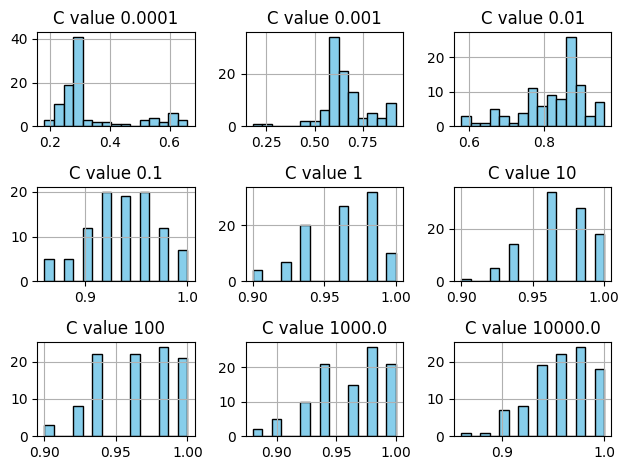

In [27]:
repetitions = 100

Cs = [1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100, 1e3, 1e4 ]


fig, axs = plt.subplots(3, 3)

axs = axs.ravel()
idxAx = 0
for CValue in Cs:

    accCs = np.empty(repetitions)

    for rep in range(repetitions):

        #Each repetition the sets are different

        X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.33, random_state=rep)


        clf = LogisticRegression(random_state=rep, n_jobs=10, max_iter=300, C=CValue).fit(X_train, y_train)
        
        yPred = clf.predict(X_test)

        acc = accuracy_score( y_test, yPred )

        accCs[rep] = acc

    axs[idxAx].hist(accCs, bins=15, color='skyblue', edgecolor='black')
    axs[idxAx].set_title(f"C value {CValue}")
    axs[idxAx].grid()
    idxAx+=1


plt.tight_layout()
plt.show()







Observe the 9 histograms generated by the code. For each $C$ value, determine if the accuracy is on target (Bias) and if the results are consistent (Variance).

| $C$ Value | Bias (High / OK) | Variance (High / OK) | Diagnosis (Underfit / Good / Overfit) |
| :--- | :--- | :--- | :--- |
| **0.0001** | | | |
| **0.001** | | | |
| **0.01** | | | |
| **0.1** | | | |
| **1.0** | | | |
| **10.0** | | | |
| **100.0** | | | |
| **1000.0** | | | |
| **10000.0** | | | |



### Critical Thinking Questions
1. Which $C$ value represents the most "rigid" model that refuses to learn the data?
2. Which $C$ value shows the most "unstable" performance?
3. Why is a slightly lower accuracy at $C=1.0$ often better than a "